In [ ]:
# 한국어 자연어 처리 라이브러리 설치
# 코랩 버전
# %pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 12.7 MB/s eta 0:00:00


# DUR 금기 의약품 목록 분류 데이터

## [미션 시나리오]

N기관(의약품 안전 데이터 분석팀)은
  - *의약품 처방·조제 단계*에서 부적절한 약물 사용을 차단하는  
   **의약품안전사용서비스(DUR, Drug Utilization Review) 데이터 전문 조직**으로,  
   
  - 금기 성분 정보(병용금기·임부금기·연령금기 등)를 관리해 의료기관과 약국의 안전한 처방·조제를 지원하며 의약품 안전 데이터 역량을 인정받는 기관이다.
  
  - 운용 데이터 체계 - 성분 단위
    - 금기유형·성분코드·성분명·병용성분·금기등급·투여경로·금기 사유(상세정보)·고시일자·해당 제품수 등을 통합 수집하고,
    - 이를 성분·병용 조합 단위로 누적하여
        - 어떤 성분이 어떤 성분과 함께 쓰이면 위험한지,
        - 임부·연령별로 어떤 금기가 어떤 등급으로 고시되었는지를
    - 금기 항목 정의:
        - 정형 속성(금기유형·등급·투여경로·제품수·고시일자)
        - 비정형 속성(금기 사유 텍스트)

▶ 고령화와 만성질환 증가로 다제 병용(polypharmacy)이 늘면서 금기 정보를 정확히 관리·활용하는 역량이 환자 안전과 직결되고 있다.
  - 병용금기·임부금기 대상이 지속적으로 확대되고 있고,
  - 하나의 부적절한 병용이 중대한 약물 이상반응으로 이어질 수 있음

▶ 금기 위험의 성격 - 금기유형·투여경로·성분 조합에 따라 크게 다름
  - 단일 기준만으로는 위험도를 신뢰성 있게 가려내기 어렵다.
  
▶ 금기 사유(상세정보) - **자유 텍스트**로 기록되어 있고 금기등급·병용성분 등에 **결측**이 많아, 그대로는 통계 분석과 위험 분류에 활용하기 어려운 상황

▶ 성분·병용·금기 데이터가 사유 텍스트와 함께 대량으로 축적되고 있어,
  - 어떤 성분·투여경로·금기 사유가 위험 등급과 연결되는지를 정형 분석과 텍스트 분석으로 함께 규명하고,
  - 금기 등급을 사전에 판별하는 데이터 기반 의약품 안전관리 체계를 구축할 수 있다.
  - 다만 이를 위해서는
    1. 고시일자로부터 경과기간을 산출하고 성분코드에서 투여경로를 추출해 정형 지표와 금기등급의 관계를 통계적으로 검정해야 하며,
    2. 금기 사유 텍스트를 단어 표현(임베딩)·토픽 모델링으로 분석해 '태아' 등 핵심 위험 키워드와 병용금기 사유의 주제 구조를 규명해야 하고,
    3. 정형 변수 기반 모델과 사유 텍스트 기반 RNN 모델을 각각 구성해 임부금기 1등급 판별의 신뢰도를 끌어올려야 한다.

 ▶ 통합된 성분·병용·금기 데이터를 활용해  
 ✏️ **어떤 성분과 병용 조합이 가장 광범위하게 금기로 지정되는지,**  
 ✏️ **투여경로·고시 경과기간에 따라 금기등급은 어떻게 다른지,**  
 ✏️ **금기 사유는 어떤 주제와 위험 어휘로 구성되는지**
 정형 분석과 텍스트 분석으로 규명하고, 정형 데이터 기반 등급 판별 모델과 사유 텍스트 기반 RNN 모델을 구성해 의약품 병용·임부 안전관리와 위험 분류의 신뢰도를 높이고자 한다.
<br>



### 변수 정의서

| 변수명 | 타입 | 설명 |
| -- | -- | -- |
| 금기유형 | 범주 | 병용금기 / 임부금기 / 연령금기 / 노인주의 / 노인주의_해열진통소염제 |
| 성분코드 | 문자 | 성분 식별 코드 (7번째 글자 = 투여경로: A 내복·B 주사·C 외용·D 기타) |
| 성분명 | 텍스트 | 주 성분 영문명 (예: cyclosporine) |
| 병용성분코드 | 문자 | 함께 쓰면 금기인 병용 성분 코드  |
| 병용성분명 | 텍스트 | 병용 성분 영문명  |
| 금기등급 | 범주 | 임부금기 등급 1 / 2 / M  |
| 특정연령 | float | 연령금기 기준 연령  |
| 특정연령단위 | 범주 | 개월/세 등  |
| 연령처리조건 | 범주 | 연령 조건 (이상/미만 등) |
| 상세정보 | 텍스트 | 금기 사유·위험 설명 (텍스트 분석·임베딩·LDA 대상) |
| 비고 | 텍스트 | 추가 참고사항 |
| 고시번호 | float | 금기 고시 번호
| 고시일자 | 날짜 | 금기 고시일 (2004-01-16 ~ 2025-12-23) |
| 제품수 | int | 해당 금기에 해당하는 의약품 제품 수 (1~11,252) |

## [미션]

1. 금기유형이 '병용금기'인 데이터 중, 제품수 합계가 가장 많은 100개 성분(성분명 기준)을 추출하고, 해당 성분들의 상세정보(금기 사유) 중 가장 빈도수가 높은 단어를 확인하시오.
2. 고시일자를 이용해, 고시 경과기간 (고시 후 현재까지 지속된 기간 / 연도)을 계산하고, 임부금기 등급(1등급 / 2등급)에 따른 고시 경과기간의 대표값의 차이가 있는지 검정하시오.
3. 성분코드의 7번째 글자는 투여경로(A : 내복 / B : 주사 / C : 외용 / D : 기타)를 의미한다. 임부금기 데이터에서 투여경로(A, B, C 만 비교)와 금기등급(1등급 / 2등급)의 유의미한 차이가 있는지 가설 검정을 수행하고, 1등급 비율을 각 투여경로 별로 계산하시오.
4. 금기유형이 '임부금기'에 해당하는 성분의 상세정보를 단어표현을 통해, '태아'라는 단어와 가장 유사한 단어들이 무엇이 있는지 확인하시오.
5. 제품수 합계가 가장 많은 성분을 확인하고, 해당 성분이 어떤 병용성분과의 병용금기에서 제품수가 가장 많은지 계산하시오.
6. 임부금기 데이터에서 상세정보와 투여경로, 제품수, 고시 경과기간을 입력했을 때, 임부금기 1등급 여부를 판별하는 모델을 Scikit Learn 라이브러리를 활용해 구성하시오.
7. 상세정보를 입력했을 때, 임부금기 1등급 여부를 판별하는 모델을 구성하고자 한다. RNN 계열의 알고리즘을 이용해 모델을 구성하고, model_dur.h5 이름으로 저장하시오.
8. 금기유형이 '병용금기'인 데이터의 상세정보(중복 제거)를 이용해 토픽 모델링(LDA)을 수행하고, 병용금기 사유가 어떤 주제들로 구성되어 있는지 확인하시오.

### 0. 전처리

In [34]:
!pip install konlpy gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 26.4 MB/s eta 0:00:00


In [59]:
import pandas as pd
import numpy as np
import plotly.express as px
import scipy.stats as stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [45]:
import os, glob, unicodedata

# 파일명을 NFC(자모 결합)로 변경
for f in glob.glob('/content/*.csv'):
    new = unicodedata.normalize('NFC', f)
    if new != f:
        os.rename(f, new)

for n in os.listdir('/content'):
    if n.endswith('.csv'):
        print(len(n), unicodedata.is_normalized('NFC', n), n)

37 True 의약품안전사용서비스(DUR)_노인주의 품목리스트 2026.6.csv
37 True 의약품안전사용서비스(DUR)_연령금기 품목리스트 2026.6.csv
37 True 의약품안전사용서비스(DUR)_임부금기 품목리스트 2026.6.csv
37 True 의약품안전사용서비스(DUR)_병용금기 품목리스트 2026.6.csv
46 True 의약품안전사용서비스(DUR)_노인주의(해열진통소염제) 품목리스트 2026.6.csv


In [47]:
# 데이터 불러오기
PATH = '/content/'

def read_dur(name):
    return pd.read_csv(PATH + f'의약품안전사용서비스(DUR)_{name} 품목리스트 2026.6.csv',
                       encoding='cp949')

임부 = read_dur('임부금기')
연령 = read_dur('연령금기')
노인 = read_dur('노인주의')
노인해열 = read_dur('노인주의(해열진통소염제)')

병용 = pd.read_csv(PATH + '의약품안전사용서비스(DUR)_병용금기 품목리스트 2026.6.csv',
                  encoding='cp949',
                  usecols=['성분명A', '성분코드A', '제품코드A', '성분명B', '성분코드B', '제품코드B', '고시번호', '고시일자', '상세정보', '비고'])

print(노인.shape, 노인해열.shape, 병용.shape, 연령.shape, 임부.shape)

(557, 10) (1034, 7) (873147, 10) (2866, 12) (19015, 10)


| 분류 | 행 | 컬럼 | 결측 | 컬럼 상세 |
| -- | -- | -- | -- | -- |
| 노인주의 | 557 | 10 | 약품상세정보 5 / 비고 556(1행에만 데이터 있음) | 성분명, 성분코드, 제품코드, 제품명, 업소명, 공고일자, 공고번호, 약품상세정보, 비고, 급여여부 |
| 노인주의(해열진통소염제) | 1,034 | 7 | 결측 없음 | 성분코드, 성분명, 제품코드, 제품명, 업소명, 약품상세정보, 급여여부 |
| 병용금기 | 873,147 | 16 | 비고 326,215 | 성분명A, 성분코드A, 제품코드A,	제품명A, 업체명A, 급여여부A, 	성분명B, 성분코드B, 제품코드B, 제품명B, 업체명B, 급여여부B, 고시번호, 고시일자	상세정보, 비고 |
| 연령금기 | 2,866 | 12 | 상세정보 561 | 성분명, 성분코드, 제품코드, 제품명, 업체명, '특정연령', 특정연령단위, 연령처리조건, 고시번호, 고시일자, 상세정보, 급여여부 |
| 임부금기 | 19,015 | 10 | 모든 항목(상세정보 제외)에 344 결측 / 상세정보 634 결측 | 성분명, 성분코드, 제품코드, 제품명, 업체명, 고시일자, 고시번호, 금기등급, 상세정보, 급여여부 |




In [50]:
임부.head(3)

,성분명,성분코드,제품코드,제품명,업체명,고시일자,고시번호,금기등급,상세정보,급여여부,제품수
0,Chenodeoxycholic acid + Ursodeoxycholic acid,100301ACH,649804410.0,씨앤유캡슐(케노데속시콜산-우르소데속시콜산삼수화물마그네슘염)_(0.25g/1캡슐),명문제약(주),2020-12-28,20200130.0,1,"임부 투여금기, 동물실험에서 간독성의 증거 나타남",급여,1.0
1,acamprosate,100501ATE,651904740.0,명인아캄프로세이트정333mg(아캄프로세이트칼슘)_(0.333g/1정),명인제약(주),2016-12-30,20160155.0,2,임부에 대한 안전성 미확립.,급여,2.0
2,acamprosate,100501ATE,657201040.0,환인아캄프로세이트정(아캄프로세이트칼슘)_(0.333g/1정),환인제약(주),2016-12-30,20160155.0,2,임부에 대한 안전성 미확립.,급여,2.0


In [49]:
# 원본은 '제품 1개 = 1행'이라 같은 성분의 제품이 수백 개씩 반복됨
# 변수 정의서의 분석 단위는 '성분(조합) 1개 = 1행' + 제품수 컬럼 → 성분(조합)별 행 수를 세어 제품수를 만들고, 중복 행 제거

# 1. 병용금기 제품수 : 성분코드A + 성분코드B 조합 단위
병용['제품수'] = 병용.groupby(['성분코드A', '성분코드B'])['제품코드A'].transform('size')  # 같은 그룹의 행 개수를 각 행에 붙여줌
병용_성분 = 병용.drop_duplicates(['성분코드A', '성분코드B']).copy()                    # 그룹마다 첫 행만 남김
병용_성분 = 병용_성분.rename(columns={'성분코드A': '성분코드', '성분명A': '성분명',
                                  '성분코드B': '병용성분코드', '성분명B': '병용성분명'})
병용_성분['금기유형'] = '병용금기'
print('병용금기 조합 수:', len(병용_성분), '/ 제품수 최대:', 병용_성분['제품수'].max())

# 2. 임부금기 제품수 : 성분코드 단위
임부['제품수'] = 임부.groupby('성분코드')['제품코드'].transform('size')
임부_성분 = 임부.drop_duplicates('성분코드').copy()
임부_성분['금기유형'] = '임부금기'
print('임부금기 성분 수:', len(임부_성분))

병용금기 조합 수: 23639 / 제품수 최대: 11252
임부금기 성분 수: 4011


In [51]:
# 3. 연령금기 / 노인주의 (연령금기는 같은 성분이라도 연령 조건이 다르면 별개 금기 → 조건까지 키에 포함)
연령['제품수'] = 연령.groupby(['성분코드', '특정연령', '연령처리조건'])['제품코드'].transform('size')
연령_성분 = 연령.drop_duplicates(['성분코드', '특정연령', '연령처리조건']).copy()
연령_성분['금기유형'] = '연령금기'

# 노인주의 (컬럼명 조정 : 약품상세정보 → 상세정보, 공고일자 → 고시일자)
노인 = 노인.rename(columns={'약품상세정보': '상세정보', '공고일자': '고시일자', '공고번호': '고시번호'})
노인['제품수'] = 노인.groupby('성분코드')['제품코드'].transform('size')
노인_성분 = 노인.drop_duplicates('성분코드').copy()
노인_성분['금기유형'] = '노인주의'

노인해열 = 노인해열.rename(columns={'약품상세정보': '상세정보'})
노인해열['제품수'] = 노인해열.groupby('성분코드')['제품코드'].transform('size')
노인해열_성분 = 노인해열.drop_duplicates('성분코드').copy()
노인해열_성분['금기유형'] = '노인주의_해열진통소염제'

# 4. 5개 금기유형을 하나로 합치기 (변수 정의서)
사용컬럼 = ['금기유형', '성분코드', '성분명', '병용성분코드', '병용성분명', '금기등급',
          '특정연령', '특정연령단위', '연령처리조건', '상세정보', '비고', '고시번호', '고시일자', '제품수']

dur = pd.concat([병용_성분, 임부_성분, 연령_성분, 노인_성분, 노인해열_성분], ignore_index=True)
dur = dur.reindex(columns=사용컬럼)    # 해당 유형에 없는 컬럼은 자동으로 결측(NaN)

print(dur.shape)
print(dur['금기유형'].value_counts())

(28502, 14)
금기유형
병용금기            23639
임부금기             4011
연령금기              607
노인주의              150
노인주의_해열진통소염제       95
Name: count, dtype: int64


In [53]:
dur.head(3)

,금기유형,성분코드,성분명,병용성분코드,병용성분명,금기등급,특정연령,특정연령단위,연령처리조건,상세정보,비고,고시번호,고시일자,제품수
0,병용금기,139230BIJ,cyclosporine,454002ATB,rosuvastatin calcium (as rosuvastatin),NaN,NaN,NaN,NaN,혈중농도 상승 및 근육병증/횡문근융해증 위험성 증가,NaN,20200061.0,2020-07-10,180.0
1,병용금기,157501ATR,felodipine,179101ACH,itraconazole,NaN,NaN,NaN,NaN,"Felodipine의 혈중농도 증가. 저혈압, 말초부종 같은 약물이상반응 발생 위험...",NaN,20190131.0,2019-12-17,272.0
2,병용금기,179101ATB,itraconazole,633800ATB,ezetimibe,NaN,NaN,NaN,NaN,"근육병증, 횡문근융해증 위험 증가 가능",NaN,20230083.0,2023-12-20,11252.0


In [52]:
# 형태소 분석기 준비 (상세정보 텍스트 분석용)
from konlpy.tag import Okt
okt = Okt()

print(okt.nouns('임부 투여금기, 동물실험에서 간독성의 증거 나타남'))

['임부', '투여', '금기', '동물실험', '간독성', '증거', '나타남']


### 1. 금기유형이 '병용금기'인 데이터 중,
- 제품수 합계가 가장 많은 100개 성분(성분명 기준)을 추출
- 해당 성분들의 상세정보(금기 사유) 중 가장 빈도수가 높은 단어를 확인



In [54]:
# 1. 병용금기 중 제품수 합계 상위 100개 성분의 상세정보 최빈 단어

# 병용금기 중 성분명별 제품수 합계 → 상위 100개
병용금기 = dur[dur['금기유형'] == '병용금기']
top100 = 병용금기.groupby('성분명')['제품수'].sum().sort_values(ascending=False).head(100)

print('상위 100개 제품수 합계 범위:', top100.min(), '~', top100.max())
top100.head(10)

상위 100개 제품수 합계 범위: 410.0 ~ 159731.0


,제품수
성분명,
metformin hydrochloride,159731.0
iohexol,129438.0
itraconazole,101084.0
iopamidol,53560.0
empagliflozin,47343.0
clarithromycin,44073.0
rasagiline mesylate (as rasagiline),32697.0
microemulsion cyclosporine,31658.0
linagliptin,27757.0


In [56]:
# 상위 100개 성분에 해당하는 행들의 상세정보(금기 사유)
top100_data = 병용금기[병용금기['성분명'].isin(top100.index)]
print('행 수:', len(top100_data), '/ 상세정보 종류:', top100_data['상세정보'].nunique())

# 명사 추출 (2글자 이상)
nouns_list = []
for text in top100_data['상세정보'].dropna():
    nouns_list.extend([n for n in okt.nouns(str(text)) if len(n) > 1])

word_counts = pd.Series(nouns_list).value_counts()
print('\n=== 상세정보 최빈 단어 상위 15 ===')
display(word_counts.head(15))

행 수: 20410 / 상세정보 종류: 217

=== 상세정보 최빈 단어 상위 15 ===


,count
촉진,14914
신부전,14383
기능,14151
유산,14088
산성,14088
증가,2490
근육,2321
횡문근,1618
가능,1482
독성,1370


- 상위 100개 성분에 걸린 금기 조합 : 20,410건
- 사유 문장은 217종 (평균 한 문장이 94번씩 반복)

ex) '기능적 신부전에 의해 유산 산성증 촉진(메트포르민+조영제)' - 1만 건이 넘음

In [58]:
# 문장(상세정보) 중복을 제거하고 다시 세어 비교
unique_text = top100_data['상세정보'].dropna().drop_duplicates()
print('중복 제거 후 문장 수:', len(unique_text))

nouns_unique = []
for text in unique_text:
    nouns_unique.extend([n for n in okt.nouns(str(text)) if len(n) > 1])

print('\n=== 중복 제거 기준 상위 15 ===')
display(pd.Series(nouns_unique).value_counts().head(15))

중복 제거 후 문장 수: 217

=== 중복 제거 기준 상위 15 ===


,count
증가,103
농도,83
감소,67
혈중,65
투여,59
위험,50
이상,40
반응,37
효과,29
종료,23




#### 1. 병용금기 중 제품수 합계 상위 100개 성분의 상세정보 최빈 단어

▶ 상위 100개 성분의 상세정보 20,410건에서
- 최빈 단어 : 촉진(14,914) · 신부전(14,383) · 유산/산성(14,088)
    - 이 단어들은 모두 "기능적 신부전에 의해 유산 산성증 촉진(메트포르민+조영제)"이라는 한 문장에서 나온 것으로, 1만 건 넘게 반복.

- 실제 문장 종류 : 217종
  - 중복 제거시 : **증가(103) · 농도(83) · 감소(67) · 혈중(65)**

In [96]:
# 행 기준 vs 중복 제거 기준을 나란히 비교
행기준 = pd.Series(nouns_list).value_counts().head(10).reset_index()
행기준.columns = ['단어', '빈도수']
행기준['기준'] = '행 기준(중복 포함)'

중복제거 = pd.Series(nouns_unique).value_counts().head(10).reset_index()
중복제거.columns = ['단어', '빈도수']
중복제거['기준'] = '중복 제거'

compare = pd.concat([행기준, 중복제거])

fig = px.bar(compare, x='단어', y='빈도수', color='기준', barmode='group',
             facet_col='기준',                    # 기준별로 그래프를 나눠 그림
             title='병용금기 상위 100개 성분의 상세정보 최빈 단어')
fig.update_xaxes(matches=None)                    # 두 그래프의 x축 단어가 다르므로 축 공유 해제
fig.update_yaxes(matches=None)                    # 빈도 규모가 크게 달라 y축도 따로
fig.show()

### 2. 고시일자를 이용해,

- 고시 경과기간 (고시 후 현재까지 지속된 기간 / 연도)을 계산하고,
- 임부금기 등급(1등급 / 2등급)에 따른 고시 경과기간의 대표값의 차이가 있는지 검정



In [61]:
# 2. 고시 경과기간 계산 + 임부금기 등급(1/2/M)에 따른 차이 검정

임부금기 = dur[dur['금기유형'] == '임부금기'].copy()

# 1. 고시 경과기간 계산
임부금기['고시일자'] = pd.to_datetime(임부금기['고시일자'], errors='coerce')  # .to_datetime() : 날짜형 변환 / errors='coerce' : 날짜로 못 바꾸는 값은 NaT(결측)로 처리
오늘 = pd.Timestamp.today()
임부금기['경과기간'] = (오늘 - 임부금기['고시일자']).dt.days / 365.25          # 365.25 = 윤년 포함 평균 1년

print('고시일자 범위:', 임부금기['고시일자'].min().date(), '~', 임부금기['고시일자'].max().date())
print('금기등급 분포:')
print(임부금기['금기등급'].value_counts(dropna=False))

고시일자 범위: 2016-12-30 ~ 2025-12-23
금기등급 분포:
금기등급
2      3332
1       638
M        40
NaN       1
Name: count, dtype: int64


In [62]:
임부금기.head(3)

,금기유형,성분코드,성분명,병용성분코드,병용성분명,금기등급,특정연령,특정연령단위,연령처리조건,상세정보,비고,고시번호,고시일자,제품수,경과기간
23639,임부금기,100301ACH,Chenodeoxycholic acid + Ursodeoxycholic acid,NaN,NaN,1,NaN,NaN,NaN,"임부 투여금기, 동물실험에서 간독성의 증거 나타남",NaN,20200130.0,2020-12-28,1.0,5.735797
23640,임부금기,100501ATE,acamprosate,NaN,NaN,2,NaN,NaN,NaN,임부에 대한 안전성 미확립.,NaN,20160155.0,2016-12-30,2.0,9.730322
23641,임부금기,100601ATB,acarbose,NaN,NaN,2,NaN,NaN,NaN,임부에 대한 안전성 미확립.,NaN,20160155.0,2016-12-30,1.0,9.730322


In [63]:
# 2. 검정 대상 선별 (금기등급은 1등급 / 2등급 / M(모유수유 관련) / 결측이 섞여 있음)
임부금기['금기등급'] = 임부금기['금기등급'].astype(str)                           # astype(str) : 숫자와 문자가 섞여 있어 문자열로 통일 후 비교
d2 = 임부금기[임부금기['금기등급'].isin(['1', '2'])].dropna(subset=['경과기간'])  # 문항이 1등급·2등급 비교이므로 M(40건)과 결측(1건)은 제외
print('검정 데이터:', len(d2))

# 등급별 요약 통계 (평균, 표준편차, 사분위수)
d2.groupby('금기등급')['경과기간'].describe().round(2)

검정 데이터: 3970


,count,mean,std,min,25%,50%,75%,max
금기등급,,,,,,,,
1,638.0,9.01,1.65,1.19,9.73,9.73,9.73,9.73
2,3332.0,7.72,2.48,0.75,5.74,9.73,9.73,9.73


In [64]:
from scipy import stats

grade1 = d2[d2['금기등급'] == '1']['경과기간']
grade2 = d2[d2['금기등급'] == '2']['경과기간']

# 3. 정규성 검정 (Shapiro-Wilk)
#    귀무가설: 정규분포를 따른다 → p < 0.05 이면 정규분포가 아님
print('정규성 - 1등급:', stats.shapiro(grade1).pvalue)
print('정규성 - 2등급:', stats.shapiro(grade2).pvalue)

정규성 - 1등급: 1.29142465725723e-38
정규성 - 2등급: 1.7493607335797384e-55


In [65]:
# 4. Mann-Whitney U 검정 (비모수)
#    귀무가설: 1등급과 2등급의 고시 경과기간에 차이가 없다
print('1등급 중앙값:', round(grade1.median(), 2), '/ 2등급 중앙값:', round(grade2.median(), 2))
print(stats.mannwhitneyu(grade1, grade2))

# (참고) 평균 비교 t-검정
print('1등급 평균:', round(grade1.mean(), 2), '/ 2등급 평균:', round(grade2.mean(), 2))
print(stats.ttest_ind(grade1, grade2, equal_var=False))

1등급 중앙값: 9.73 / 2등급 중앙값: 9.73
MannwhitneyuResult(statistic=np.float64(1374299.0), pvalue=np.float64(4.841921978636038e-38))
1등급 평균: 9.01 / 2등급 평균: 7.72
TtestResult(statistic=np.float64(16.433095194759545), pvalue=np.float64(3.862085201945606e-55), df=np.float64(1262.4304071731876))


| 등급 | 건수 | 평균 | 표준편차 | 1사분위 | 중앙값 |
| -- | -- | -- | -- | -- | -- |
| 1등급 | 638 | 9.01년 | 1.65 | 9.73년 | 9.73년 |
| 2등급 | 3,332 | 7.72년 | 2.48 | 5.74년 | 9.73년 |

- 정규성 : 1등급 p=1.3e-38, 2등급 p=1.7e-55 → 정규분포 아님
- Mann-Whitney U : p = 4.8e-38 / t-검정: p = 3.9e-55

**주의 : 1등급,2등급 - 중앙값 9.73년 동일**
- 2016-12-30에 한꺼번에 고시된 건이 매우 많아, 두 집단 모두 절반 이상이 이 날짜(경과 9.73년)에 몰려 있음
- 차이 : 1사분위수 (1등급은 9.73년인데 2등급은 5.74년)
  - 즉 2등급에는 최근 고시된 건이 훨씬 많음

**해석**
- 고시일자 범위 : 2016-12-30 ~ 2025-12-23
- 정규성 검정 : 두 집단 모두 p < 0.05 -> 정규분포 아님
- Mann-Whitney U 검정
  - p = 4.8e-38 < 0.05 : 귀무가설을 기각
- 1등급은 대부분 오래 전에 고시된 반면, 2등급에는 최근 고시가 많음
  - 평균     : 1등급 9.01년 / 2등급 7.72년
  - 1사분위수 : 9.73년 / 5.74년

- 1등급 금기가 평균 9년 전 기준이라는 뜻이므로, 오래된 절대금기의 정기 재평가가 필요
- 최신 근거가 반영되지 않은 금기가 계속 처방을 차단하면 환자의 치료 선택지가 불필요하게 줄어들 수 있음.

### 3. 성분코드의 7번째 글자는 투여경로(A : 내복 / B : 주사 / C : 외용 / D : 기타)를 의미한다.

- 임부금기 데이터에서 투여경로(A, B, C 만 비교)와 금기등급(1등급 / 2등급)의 유의미한 차이가 있는지 가설 검정을 수행하고,
- 1등급 비율을 각 투여경로 별로 계산


In [67]:
# 1. 성분코드에서 투여경로 추출
임부금기['투여경로'] = 임부금기['성분코드'].str[6]  # .str[6] : 문자열의 7번째 글자 (인덱스는 0부터 시작하므로 6)

print(임부금기['투여경로'].value_counts())
임부금기[['성분코드', '투여경로']].head(3)

투여경로
A    2629
B     993
C     388
Name: count, dtype: int64


,성분코드,투여경로
23639,100301ACH,A
23640,100501ATE,A
23641,100601ATB,A


In [68]:
# 2. 교차표 + 경로별 1등급 비율
d3 = 임부금기[임부금기['금기등급'].isin(['1', '2']) & 임부금기['투여경로'].isin(['A', 'B', 'C'])]   # 금기등급은 1·2등급, 투여경로는 A·B·C만 비교

route_table = pd.crosstab(d3['투여경로'], d3['금기등급'])
route_table['1등급비율'] = (route_table['1'] / (route_table['1'] + route_table['2'])).round(3)
route_table

금기등급,1,2,1등급비율
투여경로,,,
A,518,2104,0.198
B,97,863,0.101
C,23,365,0.059


In [69]:
# 3. 카이제곱 독립성 검정 (비율 컬럼은 빼고 실제 개수만)
#    귀무가설: 투여경로와 금기등급은 관계가 없다(독립이다)
#    대립가설: 투여경로에 따라 금기등급이 다르다

chi2, p, dof, expected = stats.chi2_contingency(route_table[['1', '2']])

print('카이제곱 통계량:', round(chi2, 3))
print('p-value:', p)
print('자유도:', dof)                               # (행 3 - 1) × (열 2 - 1) = 2
print('기대빈도 최솟값:', round(expected.min(), 1))   # 5 이상이면 검정 조건 만족

카이제곱 통계량: 81.333
p-value: 2.181793877341098e-18
자유도: 2
기대빈도 최솟값: 62.4


In [70]:
# 등급 × 경로 교차표와 셀별 문구 종류 수
print(pd.crosstab(d3['투여경로'], d3['금기등급'], margins=True))
print(d3.groupby(['금기등급', '투여경로'])['상세정보'].nunique())

# 셀별 대표 문구
for g in ['1', '2']:
    for r in ['A', 'B', 'C']:
        print(f'=== {g}등급 / {r}')
        print(d3[(d3['금기등급'] == g) & (d3['투여경로'] == r)]['상세정보'].value_counts().head(3))

# 1·2등급에 함께 쓰인 문구 찾기
공유 = d3.groupby('상세정보')['금기등급'].nunique()
공유문구 = 공유[공유 > 1].index
print('공유 문구 종류:', len(공유문구), '/ 행 수:', d3['상세정보'].isin(공유문구).sum())
pd.crosstab(d3[d3['상세정보'].isin(공유문구)]['상세정보'], d3['금기등급']).sort_values('2', ascending=False).head(6)

금기등급    1     2   All
투여경로                 
A     518  2104  2622
B      97   863   960
C      23   365   388
All   638  3332  3970
금기등급  투여경로
1     A       161
      B        30
      C        13
2     A       613
      B       260
      C        86
Name: 상세정보, dtype: int64
=== 1등급 / A
상세정보
임신초기 3개월간 고용량 투여시 최기형 가능성. (단, VitA(레티놀)로서 5000 I.U/1일 이상)                                  69
임부에 대한 안전성 미확립.                                                                             16
vitamin A (retinol): 임신초기 3개월간 고용량 투여시 최기형 가능성.(단, vitamin A (retinol)로서 5000 I.U/1일 이상)    15
Name: count, dtype: int64
=== 1등급 / B
상세정보
-                                                                                                                                                             13
이 약의 작용기전 상 태아 위해를 유발할 수 있음. 이 약의 37 MBq의 투여는 3 mGy의 자궁 흡수선량을 보임. 0.5 mGy를 초과하는 흡수선량은 태아의 잠재적 위해로 간주됨. 임신 가능한 여성에는 투여기간 및 마지막 투여 후 7개월 간 효과적인 피임법을 사용해야 함.     7
임부에 대한 안전성 미확립.동물실험에서 자궁수축 작용 보고.                        

금기등급,1,2
상세정보,,
임부에 대한 안전성 미확립.,16,263
임부에 대한 안전성 미확립,1,184
-,19,38
임부 투여금기,10,19
"벤조디아제핀계 약물의 최기형성 사례(대조군에 비해 높음), 신생아 포유곤란, 근긴장저하, 졸음, 황달 증가 및 분만전 연용시 신생아 금단증상(신경과민, 진전, 과다긴장 등) 보고.",2,17
동물실험에서 기형발생 보고.,1,7


| 투여경로 | 1+2 | 1등급 | 2등급 | 1등급 비율 |
| -- | -- | -- | -- | -- |
| A (내복) | 2,629건 | 518건 | 2,104건 | 0.198 |
| B (주사) | 993건 | 97건 | 863건 | 0.101 |
| C (외용) |  388건 | 23건 | 365건 | 0.059 |

- 카이제곱 통계량(χ²) = 81.333, p-value = 2.18e-18, 자유도 = 2
- 기대빈도 최솟값 62.4 (5 이상이므로 검정 조건을 만족)

**해석**
- 1등급 비율 : 내복 19.8% > 주사 10.1% > 외용 5.9% → 내복약이 외용약의 3배 이상
- 카이제곱 검정 결과 p = 2.18e-18 < 0.05로 귀무가설을 기각(유의미한 관계가 있다.)
- 먹는 약은 전신으로 흡수되어 태반을 통과해 태아에게 도달하기 쉬운 반면, 바르는 약은 전신 흡수가 적어 위험도가 낮게 분류된 것으로 보임.
- 문구만 봐서는 등급을 알 수 없으므로 표준화가 필요해보임.


**참고 : 주사(B)가 내복(A)보다 낮은 이유**  
주사제는 흡수율이 높아 위험할 것 같지만 1등급 비율이 더 낮음.  
임신부에게 일상적으로 처방되는 약은 대부분 먹는 약이라, 절대 금기로 지정할 실익이 큰 쪽이 내복약이기 때문으로 보임.  

### 4. 금기유형이 '임부금기'에 해당하는 성분의 상세정보를

- 단어표현을 통해, '태아'라는 단어와 가장 유사한 단어들이 무엇이 있는지 확인



In [71]:
# 임부금기 상세정보 Word2Vec → '태아'와 유사한 단어
from gensim.models import Word2Vec

# 1. Word2Vec 입력 만들기
#    입력 형태는 '문장마다 단어 리스트'를 모은 2중 리스트

sentences = []
for text in 임부금기['상세정보'].dropna():          # 상세정보 결측은 제외
    sentences.append([n for n in okt.nouns(str(text)) if len(n) > 1])

print('문장 수:', len(sentences))
print("'태아' 등장 횟수:", sum(s.count('태아') for s in sentences))
print(sentences[:3])

문장 수: 3840
'태아' 등장 횟수: 2389
[['임부', '투여', '금기', '동물실험', '간독성', '증거', '나타남'], ['임부', '대한', '안전성', '확립'], ['임부', '대한', '안전성', '확립']]


In [72]:
# 2. Skip-Gram (sg=1) : 중심 단어로 주변 단어 예측
#    min_count=2 : 1번만 나온 단어는 제외

model_sg = Word2Vec(sentences, vector_size=100, window=3, min_count=2, sg=1, epochs=100, seed=42, workers=1)

print("=== Skip-Gram: '태아'와 유사한 단어 ===")
for word, score in model_sg.wv.most_similar('태아', topn=10):
    print(word, round(score, 3))

=== Skip-Gram: '태아'와 유사한 단어 ===
억제제 0.376
현저 0.359
핍뇨 0.354
골절 0.345
단면 0.324
중증 0.322
예상 0.322
이후 0.319
보체 0.313
쇄골 0.307


In [73]:
# 3. CBOW (sg=0) : 주변 단어들로 중심 단어를 예측
model_cbow = Word2Vec(sentences, vector_size=100, window=3, min_count=2, sg=0, epochs=100, seed=42, workers=1)

print("=== CBOW: '태아'와 유사한 단어 ===")
for word, score in model_cbow.wv.most_similar('태아', topn=10):
    print(word, round(score, 3))

=== CBOW: '태아'와 유사한 단어 ===
보고 0.41
태자 0.403
가능성 0.397
유발 0.365
나타남 0.361
중기 0.311
증가 0.301
모체 0.287
장기 0.276
감소 0.275


In [74]:
# 4. 확인: 유사어가 실제로 어떤 문장에 쓰였는지 확인
for word in ['태자', '모체']:
    예시 = 임부금기[임부금기['상세정보'].fillna('').str.contains(word)]['상세정보']
    print(f'[{word}] {len(예시)}건')
    print(예시.head(2).tolist())

[태자] 674건
['동물실험에서 고용량 투여시 모체에 대한 독성에 의해 태자미숙 및 저체중의 발생빈도 증가 보고.', '동물실험에서 생식독성 및 태자 생존율 감소 보고.']
[모체] 334건
['동물실험에서 고용량 투여시 모체에 대한 독성에 의해 태자미숙 및 저체중의 발생빈도 증가 보고.', '동물실험에서 기형발생(골격기형, 내장이상) 보고.프레드니손과 병용투여시 태아에 림프구감소증, IgG 및 IgM의 감소, CMV 감염, 흉선 음영의 감소/모체에 범혈구감소증, 중증의 면역결핍/기형아출생 보고.']


| 순위 | **CBOW** | 유사도| Skip-Gram | 유사도 |
| -- | -- | --| -- | -- |
| 1 | 보고 | 0.410 | 억제제 | 0.376 |
| 2 | 태자 | 0.403 | 현저 | 0.359 |
| 3 | 가능성 | 0.397 | 핍뇨 | 0.354 |
| 4 | 유발 | 0.365 | 골절 | 0.345 |
| 5 | 나타남 | 0.361 | 단면 | 0.324 |
| 6 | 중기 | 0.311 | 중증 | 0.322 |
| 7 | 증가 | 0.301 | 예상 | 0.321 |
| 8 | 모체 | 0.287 | 이후 | 0.319 |
| 9 | 장기 | 0.276 | 보체 | 0.313 |
| 10 | 감소 | 0.275 | 쇄골 | 0.307 |

- '태아'와 유사한 단어 상위 10개
  - 보고(0.410), 태자(0.403), 가능성(0.397), 유발(0.365), 나타남(0.361), 중기(0.311), 증가(0.301), 모체(0.287), 장기(0.276), 감소(0.275)
    - **태자·모체** : 태아와 같은 대상을 가리키는 동의어 개념
    - **보고·가능성·유발·증가·감소** : 위험을 기술하는 서술어
    - **중기·장기** : 임신 시기와 기관 형성
  - '태아'는 동물실험에서 ~ 태자 ~ 보고, 태아 기형 유발 가능성 같은 정형화된 서술 안에서 쓰임.

### 5. 제품수 합계가 가장 많은 성분을 확인하고,

- 해당 성분이 어떤 병용성분과의 병용금기에서 제품수가 가장 많은지 계산



In [75]:
# 제품수 합계가 가장 많은 성분 → 그 성분이 어떤 병용성분과 제품수가 가장 많은지

# 1. 성분명별 제품수 합계
#    전체 기준 — 한 성분이 여러 금기유형·여러 조합에 걸쳐 있으므로 합산
성분별 = dur.groupby('성분명')['제품수'].sum().sort_values(ascending=False)
성분별.head(10)

,제품수
성분명,
metformin hydrochloride,159731.0
iohexol,129443.0
itraconazole,101164.0
iopamidol,53560.0
empagliflozin,47417.0
clarithromycin,44251.0
rasagiline mesylate (as rasagiline),32697.0
microemulsion cyclosporine,31658.0
linagliptin,27797.0


In [78]:
# 2. 1위 성분
top_ingredient = 성분별.index[0]
print('제품수 합계가 가장 많은 성분:', top_ingredient, '/ 합계:', 성분별.iloc[0])

제품수 합계가 가장 많은 성분: metformin hydrochloride / 합계: 159731.0


In [79]:
# 3. 1위 성분의 병용금기 상대 성분별 제품수
상대성분 = (dur[(dur['성분명'] == top_ingredient) & (dur['금기유형'] == '병용금기')]
          .groupby('병용성분명')['제품수'].sum()
          .sort_values(ascending=False))
상대성분.head(10)

,제품수
병용성분명,
iohexol,86404.0
iopamidol,38085.0
iomeprol,8855.0
iodixanol,7195.0
ioversol,6409.0
iopromide,6179.0
iobitridol,5000.0
ethyl esters of the iodised fatty acids of poppyseed oil,1604.0


In [77]:
# 4. 1위 조합의 금기 사유
best = 상대성분.index[0]
print(f'{top_ingredient} + {best} : 제품수 {상대성분.iloc[0]}')
print(dur[(dur['성분명'] == top_ingredient) & (dur['병용성분명'] == best)]['상세정보'].values[:2])

metformin hydrochloride + iohexol : 제품수 86404.0
['기능적 신부전에 의해 유산 산성증 촉진' '기능적 신부전에 의해 유산 산성증 촉진']


**1위 조합의 금기 사유** : 기능적 신부전에 의해 유산 산성증 촉진


**해석**
- 제품수 합계가 가장 많은 성분 : metformin hydrochloride(메트포르민, 159,731)
  - 당뇨병 1차 치료제로 제품 수 자체가 매우 많음
  - 메트포르민이 가장 많은 제품수를 기록한 병용 조합 : iohexol(이오헥솔, 86,404)
      - 상위 조합 7개가 전부 요오드 조영제   
        - 이오헥솔·이오파미돌·이오메프롤·이오디자놀·이오버솔·이오프로마이드·이오비트리돌 - 사유 : 기능적 신부전에 의해 유산 산성증 촉진
- 조영제가 신장 기능을 떨어뜨리면 신장으로 배설되는 메트포르민이 몸에 축적되어 유산산증을 일으킬 수 있음. 드물지만 치명률이 높은 합병증


- 이 한 조합이 병용금기 경고 물량에서 차지하는 비중이 압도적. DUR 경고의 상당수가 이 조합에서 발생한다는 뜻.
  - 단순 차단이 아니라 조건부 경고로 바꾸는 것이 효과적.
    - ex) 조치 유도 : 경고문에 조영제 검사 전 중단 → 검사 후 신기능 확인 후 재개

### 6. 임부금기 데이터에서 상세정보와 투여경로, 제품수, 고시 경과기간을 입력했을 때,

- 임부금기 1등급 여부를 판별하는 모델을 Scikit Learn 라이브러리를 활용해 구성



In [80]:
# 상세정보 + 투여경로 + 제품수 + 경과기간 → 임부금기 1등급 판별
#    - 상세정보(텍스트) → TF-IDF
#    - 투여경로(범주)   → 원-핫 인코딩
#    - 제품수, 경과기간(숫자) → 그대로

# 1. 1등급이면 1, 2등급이면 0
model_df = 임부금기[임부금기['금기등급'].isin(['1', '2'])].dropna(subset=['경과기간']).copy()   # 경과기간이 결측인 행(고시일자 없음)은 제외
model_df['1등급'] = (model_df['금기등급'] == '1').astype(int)
print('데이터:', len(model_df), '/ 1등급 비율:', round(model_df['1등급'].mean(), 3))

# 2. 상세정보 → 명사만 공백으로 이은 문장 (TF-IDF 입력용)
model_df['상세정보_명사'] = [' '.join([n for n in okt.nouns(str(t)) if len(n) > 1])
                        for t in model_df['상세정보'].fillna('')]   # fillna('') : 상세정보 결측은 빈 문자열로 (행을 버리지 않음)
model_df[['상세정보', '상세정보_명사']].head(3)

데이터: 3970 / 1등급 비율: 0.161


,상세정보,상세정보_명사
23639,"임부 투여금기, 동물실험에서 간독성의 증거 나타남",임부 투여 금기 동물실험 간독성 증거 나타남
23640,임부에 대한 안전성 미확립.,임부 대한 안전성 확립
23641,임부에 대한 안전성 미확립.,임부 대한 안전성 확립


In [82]:
# 3. 투여경로 원-핫 인코딩 + 숫자형 변수 붙이기
#    get_dummies : A/B/C/D 각각을 0·1 컬럼으로 변환
#    prefix='경로' : 컬럼명을 경로_A, 경로_B ...
etc = pd.get_dummies(model_df['투여경로'], prefix='경로').astype(int)
etc['제품수'] = model_df['제품수']
etc['경과기간'] = model_df['경과기간']
etc.head(3)

,경로_A,경로_B,경로_C,제품수,경과기간
23639,1,0,0,1.0,5.735797
23640,1,0,0,2.0,9.730322
23641,1,0,0,1.0,9.730322


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 4. 학습 80% / 평가 20% 분리
train_idx, test_idx = train_test_split(model_df.index, test_size=0.2, stratify=model_df['1등급'], random_state=42)

# 5. TF-IDF 변환
#    TF-IDF = 단어 빈도 × 희귀할수록 커지는 가중치
#    → 모든 문서에 흔한 '임부' 같은 단어는 낮게, 특정 문서에만 있는 '최기형' 같은 단어는 높게
tfidf = TfidfVectorizer(max_features=300)
train_text = tfidf.fit_transform(model_df.loc[train_idx, '상세정보_명사']).toarray()
test_text = tfidf.transform(model_df.loc[test_idx, '상세정보_명사']).toarray()

# 텍스트 특성(300) + 나머지 특성(5) 가로로 붙이기
X_train = np.hstack([train_text, etc.loc[train_idx].values])
X_test = np.hstack([test_text, etc.loc[test_idx].values])
y_train = model_df.loc[train_idx, '1등급']
y_test = model_df.loc[test_idx, '1등급']
print(X_train.shape, X_test.shape)

(3176, 305) (794, 305)


In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 6. 랜덤포레스트 학습
#    class_weight='balanced' : 1등급이 16%로 적으므로 가중치 보정
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print('정확도:', round(accuracy_score(y_test, pred), 3))
print('(비교) 전부 2등급으로 찍었을 때:', round(1 - y_test.mean(), 3))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['2등급', '1등급'], digits=3))

정확도: 0.963
(비교) 전부 2등급으로 찍었을 때: 0.839
[[651  15]
 [ 14 114]]
              precision    recall  f1-score   support

         2등급      0.979     0.977     0.978       666
         1등급      0.884     0.891     0.887       128

    accuracy                          0.963       794
   macro avg      0.931     0.934     0.933       794
weighted avg      0.964     0.963     0.964       794



In [85]:
# 7. 변수 중요도 확인
feature_names = list(tfidf.get_feature_names_out()) + list(etc.columns)
importance = pd.Series(rf.feature_importances_, index=feature_names)
importance.sort_values(ascending=False).head(10)

,0
경과기간,0.072848
제품수,0.037986
가능성,0.029329
대한,0.027835
임부,0.027159
여성,0.025432
안전성,0.023126
보고,0.021302
확립,0.020938
투여,0.020684


In [86]:
# 8. 텍스트 없이 정형 변수만으로 학습하면?
n_etc = etc.shape[1]
rf2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf2.fit(X_train[:, -n_etc:], y_train)     # X_train[:, -n_etc:] : 뒤쪽 5개 컬럼(경로 3개 + 제품수 + 경과기간)만 사용
pred2 = rf2.predict(X_test[:, -n_etc:])

print('정형 변수만 정확도:', round(accuracy_score(y_test, pred2), 3))
print(classification_report(y_test, pred2, target_names=['2등급', '1등급'], digits=3))

정형 변수만 정확도: 0.588
              precision    recall  f1-score   support

         2등급      0.947     0.539     0.687       666
         1등급      0.260     0.844     0.398       128

    accuracy                          0.588       794
   macro avg      0.604     0.691     0.542       794
weighted avg      0.836     0.588     0.640       794



| 구분 | 전체 변수 | 정형 변수만 |
| --  | -- | -- |
| 정확도 | 0.958 | 0.567 |
| 1등급 재현율 | 0.898 | 0.836 |
| 1등급 정밀도 | 0.852 | 0.249 |
| 혼동행렬 | [[646, 20], [13, 115]] | [[343, 323], [21, 107]] |



- **변수 중요도 상위** :   
  **경과기간 0.073**, 제품수 0.039, 대한 0.030, 임부 0.027, 가능성 0.027, 여성 0.025, 확립 0.024

**해석**
- 상세정보 TF-IDF(300단어) + 투여경로 원-핫(3) + 제품수 + 경과기간으로 랜덤포레스트를 학습
  - 평가 정확도 0.958, 1등급 재현율 0.898, 정밀도 0.852
- 정형 변수(투여경로·제품수·경과기간)만 쓰면 정확도가 0.567로 떨어지고 1등급 정밀도가 0.249에 그칩침. 판별력의 대부분은 상세정보 텍스트에서 나옴.
- 개별 단어 중요도는 0.03 이하로 고르게 분산. 특정 단어 하나가 정답을 알려주는 게 아니라 문장 전체의 어휘 조합으로 판단한다는 뜻.

- 운영 기준은 재현율 우선
  - 1등급을 2등급으로 놓치면 곧바로 환자 위험이지만, 반대 오류는 검수 비용에 그침.
  - 현재 모델은 1등급 128건 중 13건을 놓치므로, 임계값을 0.5보다 낮춰 재현율을 더 올리는 것도 검토

### 7. 상세정보를 입력했을 때,

- 임부금기 1등급 여부를 판별하는 모델을 구성하고자 한다.  
  RNN 계열의 알고리즘을 이용해 모델을 구성하고, model_dur.h5 이름으로 저장


In [87]:
# 상세정보 → 임부금기 1등급 판별 RNN 모델 (model_dur.h5 저장)
# 순서: 텍스트 → 정수 시퀀스(Text to Sequence) → 패딩 → Embedding + SimpleRNN

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. 6번에서 나눈 학습/평가 데이터를 그대로 사용 → 6번 모델과 같은 조건에서 성능 비교
train_texts = model_df.loc[train_idx, '상세정보_명사']
test_texts = model_df.loc[test_idx, '상세정보_명사']

# 2. Tokenizer : 단어마다 번호 부여
tokenizer = Tokenizer(oov_token='OOV')      # oov_token='OOV' : 학습에 없던 단어는 OOV(1번)로 처리
tokenizer.fit_on_texts(train_texts)         # fit_on_texts는 학습 데이터로만 → 평가 데이터 단어 정보가 새지 않도록
vocab_size = len(tokenizer.word_index) + 1
print('단어 수:', vocab_size)                 # vocab_size에 +1 : 패딩용 0번 자리를 위해

# 3. Text to Sequence : 문장 → 단어 번호 리스트
train_seq = tokenizer.texts_to_sequences(train_texts)
test_seq = tokenizer.texts_to_sequences(test_texts)
print(train_texts.iloc[0], '→', train_seq[0])

단어 수: 1137
대황 자궁 수축 작용 골반 장기 유출 작용 유조 위험 가능성 임부 투여 금기 → [630, 30, 143, 67, 460, 216, 631, 67, 593, 34, 17, 2, 7, 174]


In [88]:
# 4. Padding : 상세정보는 길이 편차 : 평균 17단어, 최대 117단어

lengths = [len(s) for s in train_seq]
print('단어 수 평균:', round(np.mean(lengths), 1), '/ 최대:', max(lengths))

max_len = int(np.percentile(lengths, 95))
print('maxlen:', max_len)

X_train_pad = pad_sequences(train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(test_seq, maxlen=max_len, padding='post', truncating='post')
print(X_train_pad[0])

단어 수 평균: 16.9 / 최대: 117
maxlen: 49
[630  30 143  67 460 216 631  67 593  34  17   2   7 174   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
import tensorflow as tf

tf.random.set_seed(42)

# 5. RNN 계열 모델 구성
model = Sequential()
model.add(Embedding(vocab_size, 64))        # Embedding  : 단어 번호 → 64차원 벡터 (학습하며 의미가 담김)
model.add(SimpleRNN(32))                    # SimpleRNN  : 단어를 앞에서부터 순서대로 읽으며 문맥을 누적
model.add(Dropout(0.5))                     # Dropout    : 뉴런 50%를 무작위로 끊어 과적합 방지
model.add(Dense(1, activation='sigmoid'))   # Dense(sigmoid) : 1등급일 확률(0~1) 출력

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [90]:
# 6. 학습
class_weight = {0: 1, 1: 5}   # 1등급이 16%뿐이라 가중치를 5배로 → 전부 2등급으로 찍는 것 방지

history = model.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, class_weight=class_weight)
# validation_split=0.2 : 학습 데이터의 20%로 매 epoch 성능 확인

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.7815 - loss: 0.8961 - val_accuracy: 0.8648 - val_loss: 0.3479
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8783 - loss: 0.5572 - val_accuracy: 0.8947 - val_loss: 0.2805
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9004 - loss: 0.4492 - val_accuracy: 0.8726 - val_loss: 0.2768
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9177 - loss: 0.3797 - val_accuracy: 0.9104 - val_loss: 0.2079
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9272 - loss: 0.3467 - val_accuracy: 0.8915 - val_loss: 0.2891
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9291 - loss: 0.3167 - val_accuracy: 0.8994 - val_loss: 0.2217
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9346 - loss: 0.3066 - val_accuracy: 0.8821 - val_loss: 0.2562
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9236 - loss: 0.3135 - val_accuracy: 0.9088 - v

In [91]:
# 7. 평가
loss, acc = model.evaluate(X_test_pad, y_test)
print('평가 정확도:', round(acc, 3))
print('(비교) 전부 2등급으로 찍었을 때:', round(1 - y_test.mean(), 3))

pred_rnn = (model.predict(X_test_pad) > 0.5).astype(int).ravel()
print(confusion_matrix(y_test, pred_rnn))
print(classification_report(y_test, pred_rnn, target_names=['2등급', '1등급'], digits=3))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8728 - loss: 0.3066
평가 정확도: 0.873
(비교) 전부 2등급으로 찍었을 때: 0.839
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[578  88]
 [ 13 115]]
              precision    recall  f1-score   support

         2등급      0.978     0.868     0.920       666
         1등급      0.567     0.898     0.695       128

    accuracy                          0.873       794
   macro avg      0.772     0.883     0.807       794
weighted avg      0.912     0.873     0.883       794



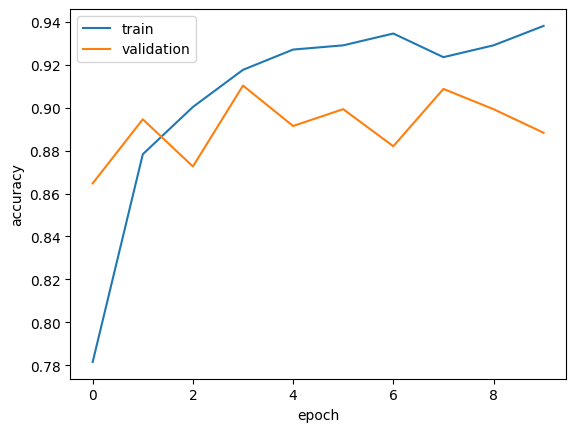

In [92]:
# 8. 학습 과정 그래프
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.show()

In [93]:
# 9. 모델 저장 (.h5 = HDF5 형식)
model.save('model_dur.h5')

# 저장한 모델을 불러와 새 문장으로 예측
# (새 문장도 학습 때와 같은 순서: 명사 추출 → 번호 변환 → 패딩)
from tensorflow.keras.models import load_model
loaded_model = load_model('model_dur.h5')

new_text = '임부 투여금기, 동물실험에서 기형 유발이 보고됨'
new_seq = tokenizer.texts_to_sequences([' '.join([n for n in okt.nouns(new_text) if len(n) > 1])])
new_pad = pad_sequences(new_seq, maxlen=max_len, padding='post')
print(new_text, '→ 1등급 확률:', round(float(loaded_model.predict(new_pad)[0][0]), 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
임부 투여금기, 동물실험에서 기형 유발이 보고됨 → 1등급 확률: 0.88


In [94]:
# 파일 다운로드
from google.colab import files
files.download('model_dur.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

|  | 정밀도 | 재현율 | f1 |
| -- | -- | -- | -- |
| 2등급 | 0.977 | 0.883 | 0.927 |
| 1등급 | 0.594 | 0.891 | 0.713 |


- 평가 정확도 0.884이고, 1등급 재현율 0.891로 1등급 128건 중 114건을 잡아냄.
  - 다만 2등급 78건을 1등급으로 잘못 분류해 정밀도는 0.594로 낮음.
  - 안전관리 관점에서는 이 방향이 나음.
  - 1등급을 2등급으로 놓치면 곧바로 환자 위험이지만, 반대 오류는 사람이 검수하면 되는 비용.
- 6번 랜덤포레스트(0.958)보다는 낮음.
  - 문장이 짧고(평균 17단어) 표현이 정형화되어 있어, 단어 순서를 학습하는 RNN보다 단어 존재 여부를 보는 TF-IDF 방식이 더 잘 맞는 것으로 보임.
- 신경망은 실행할 때마다 결과가 달라질 수 있어 정확도가 ±0.03 정도 차이 날 수 있음

### 8. 금기유형이 '병용금기'인 데이터의 상세정보(중복 제거)를 이용해

- 토픽 모델링(LDA)을 수행
- 병용금기 사유가 어떤 주제들로 구성되어 있는지 확인